<a href="https://colab.research.google.com/github/Mattalukkal/Ai_ML/blob/main/Intermediate_Assessment_HR_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [3]:
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analytics_Vidya/train_LZdllcl.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analytics_Vidya/test_2umaH9m.csv')
sample_submission_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analytics_Vidya/sample_submission_M0L0uXE.csv')

print("Train DataFrame head:")
print(train_df.head())
print("\nTest DataFrame head:")
print(test_df.head())
print("\nSample Submission DataFrame head:")
print(sample_submission_df.head())

Train DataFrame head:
   employee_id         department     region         education gender  \
0        65438  Sales & Marketing   region_7  Master's & above      f   
1        65141         Operations  region_22        Bachelor's      m   
2         7513  Sales & Marketing  region_19        Bachelor's      m   
3         2542  Sales & Marketing  region_23        Bachelor's      m   
4        48945         Technology  region_26        Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   35                   5.0   
1               other                1   30                   5.0   
2            sourcing                1   34                   3.0   
3               other                2   39                   1.0   
4               other                1   45                   3.0   

   length_of_service  KPIs_met >80%  awards_won?  avg_training_score  \
0                  8              1            0    

## Exploratory Data Analysis

Perform initial exploratory data analysis (EDA) to understand data types, check for missing values, and visualize the distribution of key features, especially the target variable 'is_promoted'.



Displaying the .info() of the train_df will provide a concise summary of the DataFrame, including data types, non-null values, and memory usage, as requested in the instructions.



In [4]:
print("Train DataFrame Info:")
train_df.info()

Train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage:


To understand the completeness of the data, I will calculate and display the number of missing values for each column in both the `train_df` and `test_df` DataFrames, as specified in the subtask instructions.



In [5]:
print("Missing values in Train DataFrame:")
print(train_df.isnull().sum())
print("\nMissing values in Test DataFrame:")
print(test_df.isnull().sum())

Missing values in Train DataFrame:
employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

Missing values in Test DataFrame:
employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64



To gain insights into the central tendency, dispersion, and shape of the numerical features, I will display descriptive statistics for the numerical columns in `train_df` using the `.describe()` method, as specified in the subtask instructions.



In [6]:
print("Descriptive statistics for numerical columns in Train DataFrame:")
print(train_df.describe())

Descriptive statistics for numerical columns in Train DataFrame:
        employee_id  no_of_trainings           age  previous_year_rating  \
count  54808.000000     54808.000000  54808.000000          50684.000000   
mean   39195.830627         1.253011     34.803915              3.329256   
std    22586.581449         0.609264      7.660169              1.259993   
min        1.000000         1.000000     20.000000              1.000000   
25%    19669.750000         1.000000     29.000000              3.000000   
50%    39225.500000         1.000000     33.000000              3.000000   
75%    58730.500000         1.000000     39.000000              4.000000   
max    78298.000000        10.000000     60.000000              5.000000   

       length_of_service  KPIs_met >80%   awards_won?  avg_training_score  \
count       54808.000000   54808.000000  54808.000000        54808.000000   
mean            5.865512       0.351974      0.023172           63.386750   
std             4.2


To understand the distribution of the target variable, I will calculate and print the value counts for 'is_promoted' in `train_df`, and then visualize this distribution using a bar plot for a clear representation, as specified in the subtask instructions.



Distribution of 'is_promoted' in Train DataFrame:
is_promoted
0    50140
1     4668
Name: count, dtype: int64


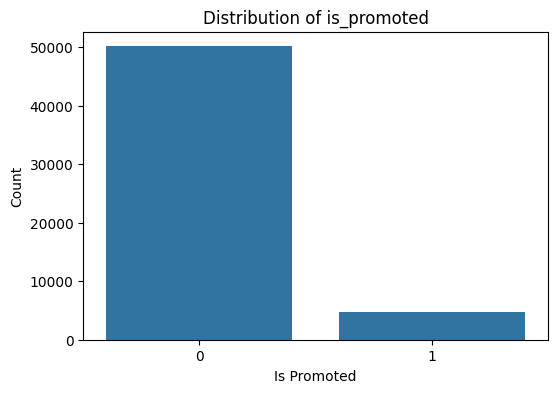

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Distribution of 'is_promoted' in Train DataFrame:")
print(train_df['is_promoted'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='is_promoted', data=train_df)
plt.title('Distribution of is_promoted')
plt.xlabel('Is Promoted')
plt.ylabel('Count')
plt.show()

## Data Preprocessing

### Subtask:
Apply necessary preprocessing steps including handling missing values using `SimpleImputer`, encoding categorical features using `LabelEncoder`, and scaling numerical features using `StandardScaler`.


**Reasoning**:
To handle missing values in 'education' and 'previous_year_rating' for both `train_df` and `test_df`, as specified in the instructions, I will initialize `SimpleImputer` with 'most_frequent' strategy for 'education' and 'median' strategy for 'previous_year_rating'. I will then fit these imputers on the respective training data columns and transform both training and test data columns.



In [11]:
print("Before imputation - Missing values in Train DataFrame:\n", train_df[['education', 'previous_year_rating']].isnull().sum())
print("Before imputation - Missing values in Test DataFrame:\n", test_df[['education', 'previous_year_rating']].isnull().sum())

# Impute missing values for 'education' with the most frequent value
edu_imputer = SimpleImputer(strategy='most_frequent')
train_df['education'] = edu_imputer.fit_transform(train_df[['education']])
test_df['education'] = edu_imputer.transform(test_df[['education']])

# Impute missing values for 'previous_year_rating' with the median value
rating_imputer = SimpleImputer(strategy='median')
train_df['previous_year_rating'] = rating_imputer.fit_transform(train_df[['previous_year_rating']])
test_df['previous_year_rating'] = rating_imputer.transform(test_df[['previous_year_rating']])

print("\nAfter imputation - Missing values in Train DataFrame:\n", train_df[['education', 'previous_year_rating']].isnull().sum())
print("After imputation - Missing values in Test DataFrame:\n", test_df[['education', 'previous_year_rating']].isnull().sum())

Before imputation - Missing values in Train DataFrame:
 education               2409
previous_year_rating    4124
dtype: int64
Before imputation - Missing values in Test DataFrame:
 education               1034
previous_year_rating    1812
dtype: int64


ValueError: 2

**Reasoning**:
The previous code failed because `SimpleImputer`'s `fit_transform` and `transform` methods return a 2D array, even for a single column. When assigning this back to a DataFrame column, it expects a 1D array or Series, leading to a `ValueError: 2`. To fix this, I need to extract the first (and only) column from the imputer's output using `[:, 0]` before assigning it back to the DataFrame columns.



In [12]:
print("Before imputation - Missing values in Train DataFrame:\n", train_df[['education', 'previous_year_rating']].isnull().sum())
print("Before imputation - Missing values in Test DataFrame:\n", test_df[['education', 'previous_year_rating']].isnull().sum())

# Impute missing values for 'education' with the most frequent value
edu_imputer = SimpleImputer(strategy='most_frequent')
train_df['education'] = edu_imputer.fit_transform(train_df[['education']]).ravel()
test_df['education'] = edu_imputer.transform(test_df[['education']]).ravel()

# Impute missing values for 'previous_year_rating' with the median value
rating_imputer = SimpleImputer(strategy='median')
train_df['previous_year_rating'] = rating_imputer.fit_transform(train_df[['previous_year_rating']]).ravel()
test_df['previous_year_rating'] = rating_imputer.transform(test_df[['previous_year_rating']]).ravel()

print("\nAfter imputation - Missing values in Train DataFrame:\n", train_df[['education', 'previous_year_rating']].isnull().sum())
print("After imputation - Missing values in Test DataFrame:\n", test_df[['education', 'previous_year_rating']].isnull().sum())

Before imputation - Missing values in Train DataFrame:
 education               2409
previous_year_rating    4124
dtype: int64
Before imputation - Missing values in Test DataFrame:
 education               1034
previous_year_rating    1812
dtype: int64

After imputation - Missing values in Train DataFrame:
 education               0
previous_year_rating    0
dtype: int64
After imputation - Missing values in Test DataFrame:
 education               0
previous_year_rating    0
dtype: int64


**Reasoning**:
Now that missing values have been handled, the next step is to encode categorical features. I will iterate through the identified categorical columns, initialize a `LabelEncoder` for each, fit it on the training data, and then transform both the training and test DataFrames accordingly.



In [13]:
categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']

for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    print(f"Column '{col}' encoded.")

print("\nTrain DataFrame head after categorical encoding:")
print(train_df.head())
print("\nTest DataFrame head after categorical encoding:")
print(test_df.head())

Column 'department' encoded.
Column 'region' encoded.
Column 'education' encoded.
Column 'gender' encoded.
Column 'recruitment_channel' encoded.

Train DataFrame head after categorical encoding:
   employee_id  department  region  education  gender  recruitment_channel  \
0        65438           7      31          2       0                    2   
1        65141           4      14          0       1                    0   
2         7513           7      10          0       1                    2   
3         2542           7      15          0       1                    0   
4        48945           8      18          0       1                    0   

   no_of_trainings  age  previous_year_rating  length_of_service  \
0                1   35                   5.0                  8   
1                1   30                   5.0                  4   
2                1   34                   3.0                  7   
3                2   39                   1.0                 10

**Reasoning**:
To scale the numerical features, I will identify the specified numerical columns, initialize a `StandardScaler`, fit it on the training data, and then transform both the training and test DataFrames for these columns, as instructed in the subtask.



In [14]:
numerical_cols = ['no_of_trainings', 'age', 'length_of_service', 'avg_training_score', 'previous_year_rating']

scaler = StandardScaler()
train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

print("\nTrain DataFrame head after numerical scaling:")
print(train_df.head())
print("\nTest DataFrame head after numerical scaling:")
print(test_df.head())


Train DataFrame head after numerical scaling:
   employee_id  department  region  education  gender  recruitment_channel  \
0        65438           7      31          2       0                    2   
1        65141           4      14          0       1                    0   
2         7513           7      10          0       1                    2   
3         2542           7      15          0       1                    0   
4        48945           8      18          0       1                    0   

   no_of_trainings       age  previous_year_rating  length_of_service  \
0        -0.415276  0.025598              1.395766           0.500460   
1        -0.415276 -0.627135              1.395766          -0.437395   
2        -0.415276 -0.104948             -0.250651           0.265996   
3         1.226063  0.547785             -1.897069           0.969387   
4        -0.415276  1.331064             -0.250651          -0.906322   

   KPIs_met >80%  awards_won?  avg_training_s

**Reasoning**:
To finalize the preprocessing, I will separate the features (X_train, X_test) and the target variable (y_train) from the preprocessed DataFrames, ensuring that 'employee_id' is dropped from all feature sets and 'is_promoted' is dropped from the training features, as per the subtask instructions.



In [15]:
X_train = train_df.drop(['employee_id', 'is_promoted'], axis=1)
y_train = train_df['is_promoted']
X_test = test_df.drop('employee_id', axis=1)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)

print("\nX_train head:")
print(X_train.head())
print("\ny_train head:")
print(y_train.head())
print("\nX_test head:")
print(X_test.head())

Shape of X_train: (54808, 12)
Shape of y_train: (54808,)
Shape of X_test: (23490, 12)

X_train head:
   department  region  education  gender  recruitment_channel  \
0           7      31          2       0                    2   
1           4      14          0       1                    0   
2           7      10          0       1                    2   
3           7      15          0       1                    0   
4           8      18          0       1                    0   

   no_of_trainings       age  previous_year_rating  length_of_service  \
0        -0.415276  0.025598              1.395766           0.500460   
1        -0.415276 -0.627135              1.395766          -0.437395   
2        -0.415276 -0.104948             -0.250651           0.265996   
3         1.226063  0.547785             -1.897069           0.969387   
4        -0.415276  1.331064             -0.250651          -0.906322   

   KPIs_met >80%  awards_won?  avg_training_score  
0              1 

**Reasoning**:
With data preprocessing complete and features/target separated, the next step is to train an XGBoost Classifier. I will define the parameter grid for `GridSearchCV` focusing on `n_estimators`, `max_depth`, and `learning_rate` to optimize for the F1 score, as specified in the task.



In [16]:
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.05]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='f1', cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score: ", grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:42:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best F1 score:  0.504589708743381


**Reasoning**:
With the best hyperparameters identified through GridSearchCV, the next step is to use the best estimator to make predictions on the preprocessed test set. These predictions will then be used to create the submission file.



In [17]:
best_xgb_model = grid_search.best_estimator_
y_pred = best_xgb_model.predict(X_test)

print("Predictions on test set generated.")
print("First 5 predictions:", y_pred[:5])
print("Shape of predictions:", y_pred.shape)

Predictions on test set generated.
First 5 predictions: [0 0 0 0 0]
Shape of predictions: (23490,)


**Reasoning**:
Now that predictions have been generated, the next step is to create the submission file by combining the 'employee_id' from the original test data with the predicted 'is_promoted' values, as required by the task.



In [18]:
submission_df = pd.DataFrame({'employee_id': test_df['employee_id'], 'is_promoted': y_pred})
submission_df.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
print(submission_df.head())

Submission file created successfully!
   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0
